<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
#!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')
#nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/alena/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [7]:
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences
for sentence in tqdm(dataset['train']['text']):
    sentences.extend(
        [x.lower() for x in sent_tokenize(sentence, language='english') if len(x) < word_threshold]
        )
    


  0%|          | 0/25000 [00:00<?, ?it/s]

In [8]:
print("Всего предложений:", len(sentences))

Всего предложений: 28827


Посчитаем для каждого слова его встречаемость.

In [9]:
sentences_other = []

for sentence in tqdm(dataset['train']['text']):
    sentences_other.extend(
        [x.lower() for x in sent_tokenize(sentence, language='english') if len(x) >= word_threshold]
        )

  0%|          | 0/25000 [00:00<?, ?it/s]

In [10]:
print("Всего предложений:", len(sentences_other))

Всего предложений: 242230


In [11]:
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(sentences_other):
    for word in word_tokenize(sentence):
        words[word] += 1

  0%|          | 0/242230 [00:00<?, ?it/s]

In [12]:
len(words)

110885

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [13]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Наполнение словаря
vocab.update([x[0] for x in words.most_common(vocab_size)])

In [14]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [15]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [16]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [17]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in self.data[idx]]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [18]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [19]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(eval_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [20]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [21]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler=None, patience=5):
    # история обучения
    history = {
        'train_loss': [],
        'val_loss': [],
        'eval_perplexities': []
    }
    
    model.to(device)
    
    # ранняя остановка
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None
    
    for epoch in range(num_epochs):
        # обучение
        model.train()
        train_loss = 0.0
        
        for batch in train_dataloader:
            data, targets = batch['input_ids'].to(device), batch['target_ids'].to(device)
            # обнуление градиентов
            optimizer.zero_grad()
            # прямой проход
            outputs = model(data).flatten(start_dim=0, end_dim=1)
            loss = criterion(outputs, targets.flatten())
            # обратный проход
            loss.backward()
            optimizer.step()
            # статистика
            train_loss += loss.item()
        # валидация
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = batch['input_ids'].to(device), batch['target_ids'].to(device)
                outputs = model(data).flatten(start_dim=0, end_dim=1)
                loss = criterion(outputs, targets.flatten())
                val_loss += loss.item()
        
        # метрики
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        eval_perplexity = evaluate(model, criterion, eval_dataloader)
        
        # обновление истории
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['eval_perplexities'].append(eval_perplexity)
        
        # обновление планировщика
        if scheduler is not None:
            scheduler.step()
        
        # вывод данных по эпохе
        current_lr = optimizer.param_groups[0]['lr']
        print(f'{epoch:^3} | Train Loss {avg_train_loss:>7.4f} | Val Loss {avg_val_loss:>7.4f} | '
              f'Perplexities {eval_perplexity:>7.2f} | LR {current_lr:>7.4f}')
        
        # ранняя остановка
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_weights = model.state_dict().copy()
            print(f"Новый лучший результат Val Loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1
            print(f"Ранняя остановка: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print("Ранняя остановка!")
                break
    
    # лучшие веса
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print("Загружены лучшие веса модели")
    
    print("Обучение завершено")
    
    return model, history

In [22]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # потери
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title('Потери')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # точность
    ax2.plot(history['eval_perplexities'], label='Eval Perplexities')
    ax2.set_title('Точность')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Perplexity')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

### Base model

In [112]:
class WordModel(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_layers, dropout):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.embedding_dim = nn.Embedding(vocab_size, hidden_dim, padding_idx=word2ind['<pad>'])
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        # эмбеддинг входных данных
        embedded = self.embedding_dim(input_batch)
        # RNN
        rnn_out, _ = self.rnn(embedded)
        # применяем dropout
        logits = self.dropout(self.linear(self.non_lin(rnn_out)))
        # логиты
        logits = self.output(self.non_lin(logits))
        
        return logits

In [113]:
base_model = WordModel(hidden_dim=256, vocab_size=len(vocab), num_layers=2, dropout=0.1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(base_model.parameters())

# обучение модели
trained_base_model, history = train_model(
    model=base_model,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=20,
    patience=5
)

 0  | Train Loss  3.5684 | Val Loss  2.9660 | Perplexities   20.16 | LR  0.0010
Новый лучший результат Val Loss: 2.9660
 1  | Train Loss  2.7886 | Val Loss  2.4555 | Perplexities   11.50 | LR  0.0010
Новый лучший результат Val Loss: 2.4555
 2  | Train Loss  2.2673 | Val Loss  2.1018 | Perplexities    8.02 | LR  0.0010
Новый лучший результат Val Loss: 2.1018
 3  | Train Loss  1.9994 | Val Loss  1.8155 | Perplexities    6.58 | LR  0.0010
Новый лучший результат Val Loss: 1.8155
 4  | Train Loss  1.8213 | Val Loss  1.5985 | Perplexities    5.73 | LR  0.0010
Новый лучший результат Val Loss: 1.5985
 5  | Train Loss  1.7082 | Val Loss  1.4480 | Perplexities    5.29 | LR  0.0010
Новый лучший результат Val Loss: 1.4480
 6  | Train Loss  1.6332 | Val Loss  1.3491 | Perplexities    5.04 | LR  0.0010
Новый лучший результат Val Loss: 1.3491
 7  | Train Loss  1.5816 | Val Loss  1.2679 | Perplexities    4.86 | LR  0.0010
Новый лучший результат Val Loss: 1.2679
 8  | Train Loss  1.5428 | Val Loss  1.2

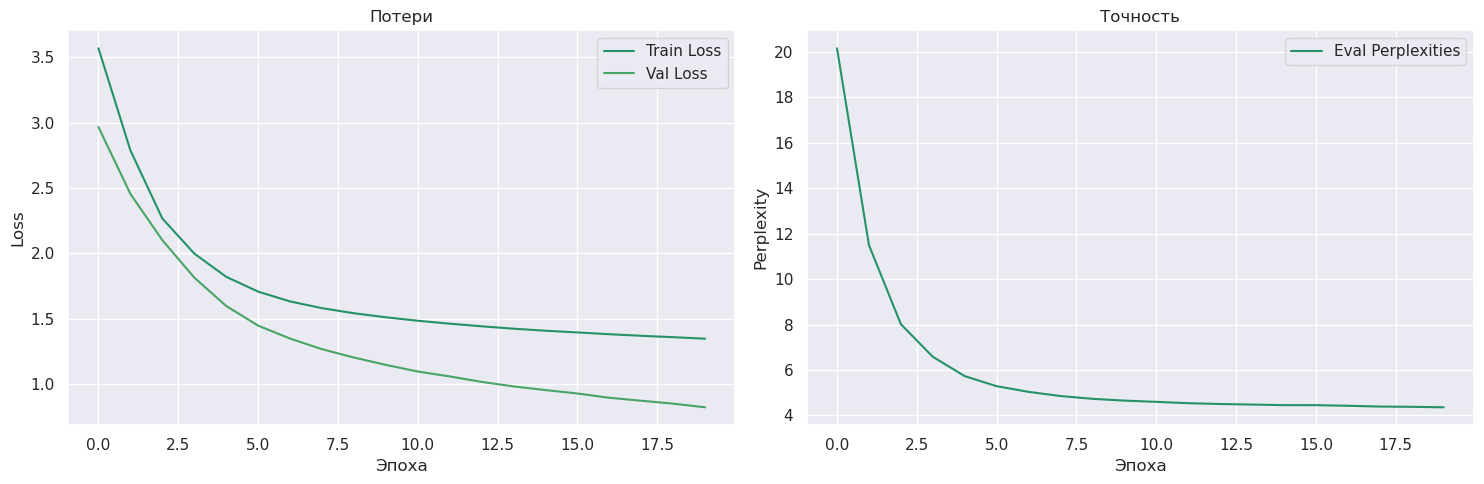

In [114]:
plot_training_history(history)

In [115]:
# оценка на тестовых данных
test_base = evaluate(trained_base_model, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия базовой модели на тесте: {test_base:.4f}")

Перплексия базовой модели на тесте: 4.3002


### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [23]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_layers, dropout):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=word2ind['<pad>'])
        self.lstm = nn.LSTM(
            hidden_dim, 
            hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_dim, vocab_size)
        self.non_lin = nn.Tanh()
        
    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_batch)
        lstm_out, _ = self.lstm(embedded)
        lstm_out = self.dropout(lstm_out)
        lstm_out = self.dropout(self.linear(self.non_lin(lstm_out)))
        logits = self.output(self.non_lin(lstm_out))
        
        return logits

#### Выбор количества слоёв

 0  | Train Loss  2.3117 | Val Loss  1.7651 | Perplexities    6.96 | LR  0.0100
Новый лучший результат Val Loss: 1.7651
 1  | Train Loss  1.8880 | Val Loss  1.5972 | Perplexities    6.12 | LR  0.0100
Новый лучший результат Val Loss: 1.5972
 2  | Train Loss  1.7959 | Val Loss  1.4802 | Perplexities    5.71 | LR  0.0100
Новый лучший результат Val Loss: 1.4802
 3  | Train Loss  1.7309 | Val Loss  1.3805 | Perplexities    5.36 | LR  0.0100
Новый лучший результат Val Loss: 1.3805
 4  | Train Loss  1.6819 | Val Loss  1.3213 | Perplexities    5.18 | LR  0.0100
Новый лучший результат Val Loss: 1.3213
Загружены лучшие веса модели
Обучение завершено


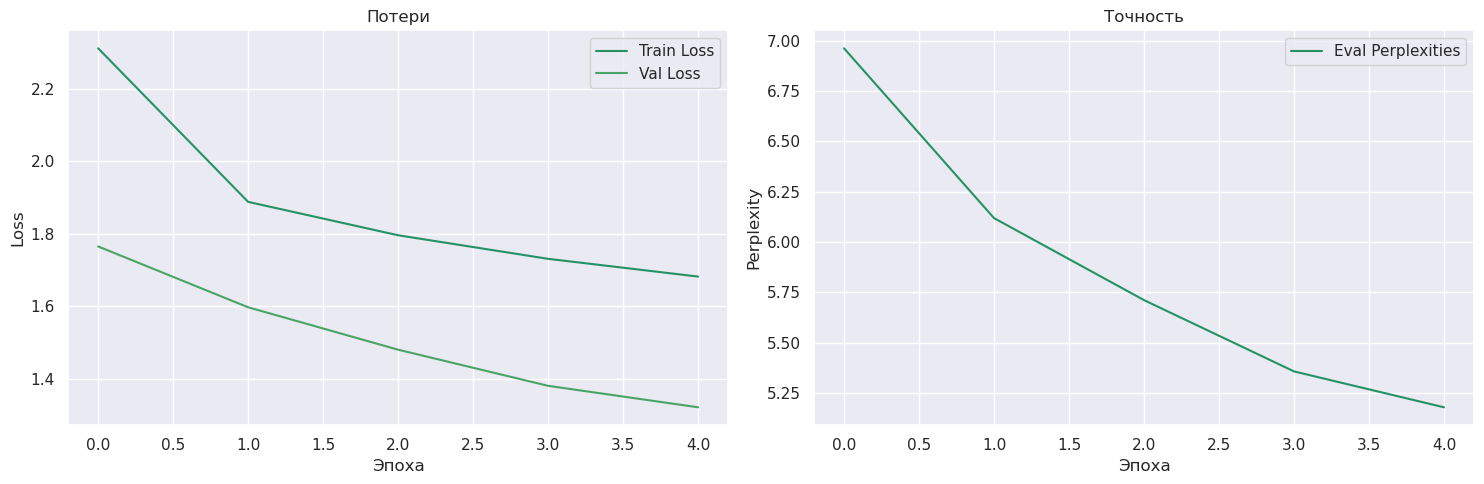

Перплексия модели на тесте: 5.1699


In [24]:
model1 = LSTMModel(hidden_dim=512, vocab_size=len(vocab), num_layers=1, dropout=0.1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

# обучение модели
trained_model1, history1 = train_model(
    model=model1,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history1)

# оценка на тестовых данных
test1 = evaluate(trained_model1, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test1:.4f}")

 0  | Train Loss  3.1899 | Val Loss  2.7308 | Perplexities   16.97 | LR  0.0100
Новый лучший результат Val Loss: 2.7308
 1  | Train Loss  2.7464 | Val Loss  2.5242 | Perplexities   14.44 | LR  0.0100
Новый лучший результат Val Loss: 2.5242
 2  | Train Loss  2.6170 | Val Loss  2.3972 | Perplexities   12.49 | LR  0.0100
Новый лучший результат Val Loss: 2.3972
 3  | Train Loss  2.5186 | Val Loss  2.3347 | Perplexities   11.72 | LR  0.0100
Новый лучший результат Val Loss: 2.3347
 4  | Train Loss  2.4609 | Val Loss  2.2823 | Perplexities   10.99 | LR  0.0100
Новый лучший результат Val Loss: 2.2823
Загружены лучшие веса модели
Обучение завершено


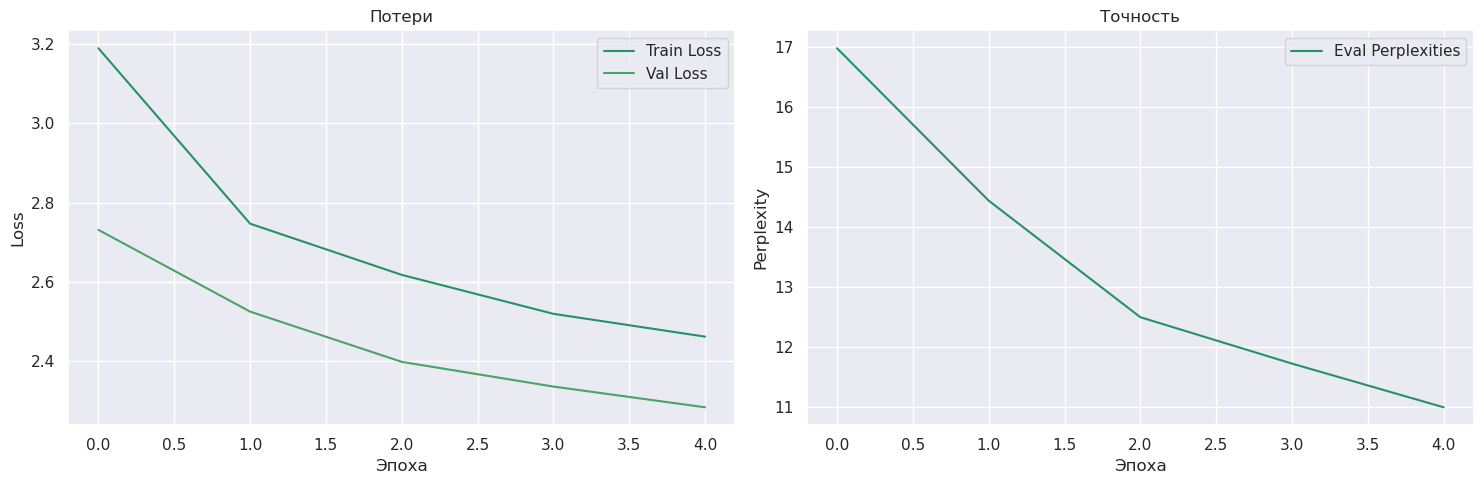

Перплексия модели на тесте: 10.9047


In [25]:
model1_1 = LSTMModel(hidden_dim=512, vocab_size=len(vocab), num_layers=2, dropout=0.1)
optimizer = torch.optim.Adam(model1_1.parameters(), lr=0.01)

# обучение модели
trained_model1_1, history1_1 = train_model(
    model=model1_1,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history1_1)

# оценка на тестовых данных
test1 = evaluate(trained_model1_1, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test1:.4f}")

 0  | Train Loss  3.3363 | Val Loss  3.1446 | Perplexities   26.52 | LR  0.0100
Новый лучший результат Val Loss: 3.1446
 1  | Train Loss  3.2278 | Val Loss  3.1549 | Perplexities   26.78 | LR  0.0100
Ранняя остановка: 1/5
 2  | Train Loss  3.2246 | Val Loss  3.1509 | Perplexities   26.67 | LR  0.0100
Ранняя остановка: 2/5
 3  | Train Loss  3.2252 | Val Loss  3.1480 | Perplexities   26.56 | LR  0.0100
Ранняя остановка: 3/5
 4  | Train Loss  3.2269 | Val Loss  3.1471 | Perplexities   26.50 | LR  0.0100
Ранняя остановка: 4/5
Загружены лучшие веса модели
Обучение завершено


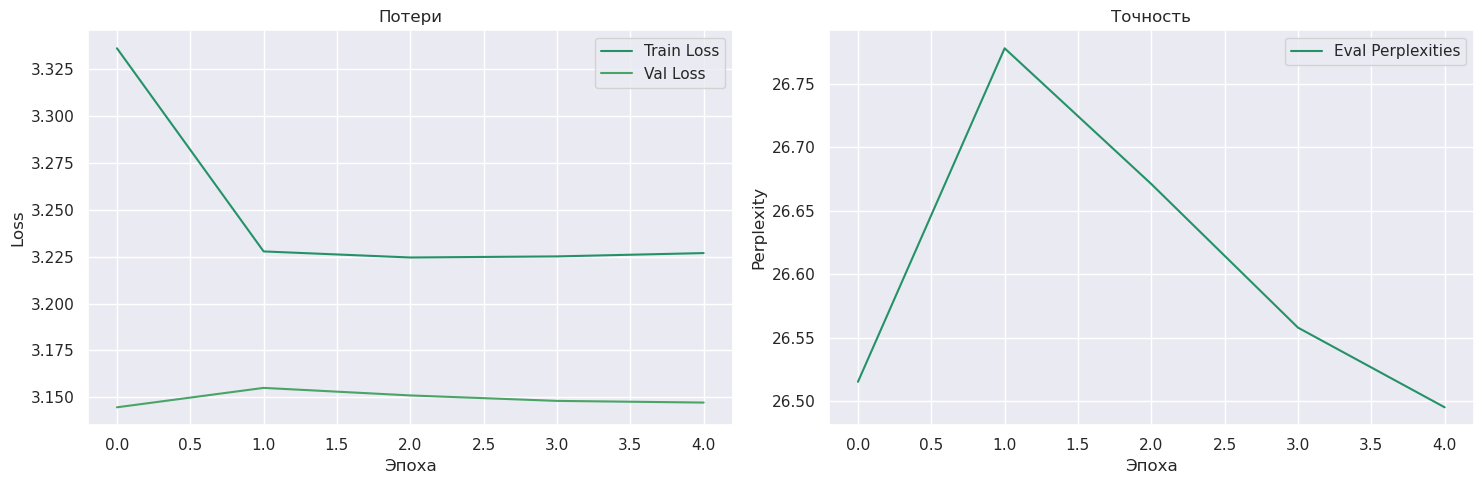

Перплексия модели на тесте: 26.3205


In [26]:
model1_2 = LSTMModel(hidden_dim=512, vocab_size=len(vocab), num_layers=3, dropout=0.1)
optimizer = torch.optim.Adam(model1_2.parameters(), lr=0.01)

# обучение модели
trained_model1_2, history1_2 = train_model(
    model=model1_2,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history1_2)

# оценка на тестовых данных
test1 = evaluate(trained_model1_2, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test1:.4f}")

1 слой: 5.2

2 слоя: 10.9

3 слоя: 26.3

Выбираем 1 слой.

#### Выбор оптимизатора

 0  | Train Loss  2.3605 | Val Loss  1.8126 | Perplexities    7.21 | LR  0.0100
Новый лучший результат Val Loss: 1.8126
 1  | Train Loss  1.9132 | Val Loss  1.6680 | Perplexities    6.33 | LR  0.0100
Новый лучший результат Val Loss: 1.6680
 2  | Train Loss  1.8190 | Val Loss  1.5403 | Perplexities    5.84 | LR  0.0100
Новый лучший результат Val Loss: 1.5403
 3  | Train Loss  1.7573 | Val Loss  1.4512 | Perplexities    5.56 | LR  0.0100
Новый лучший результат Val Loss: 1.4512
 4  | Train Loss  1.7095 | Val Loss  1.3709 | Perplexities    5.31 | LR  0.0100
Новый лучший результат Val Loss: 1.3709
Загружены лучшие веса модели
Обучение завершено


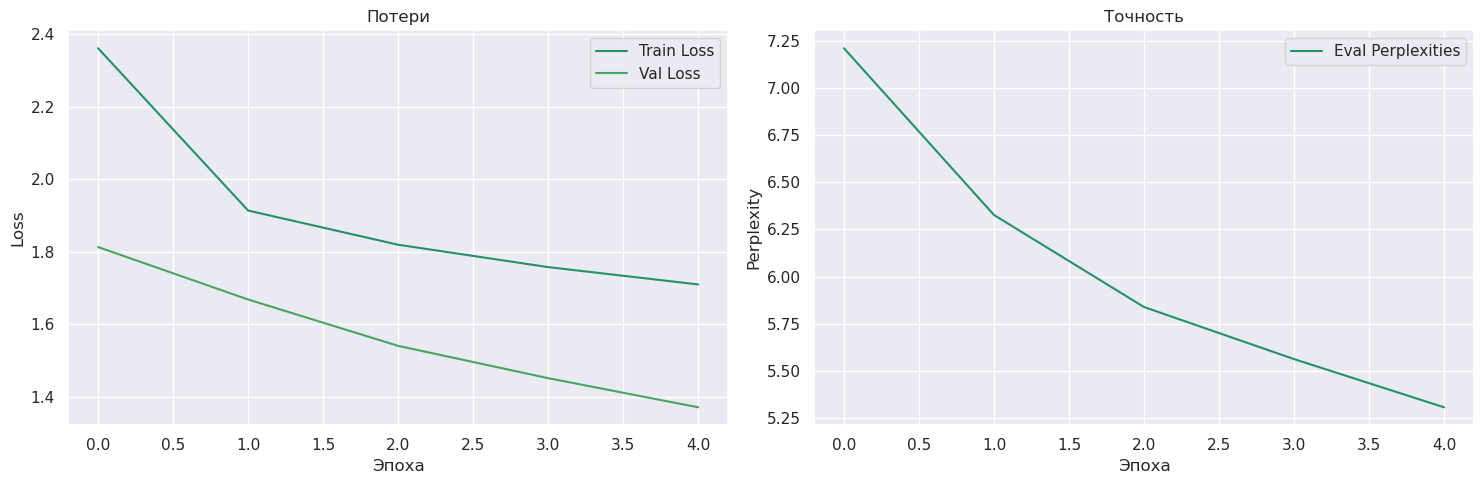

Перплексия модели на тесте: 5.2646


In [27]:
model1a = LSTMModel(hidden_dim=512, vocab_size=len(vocab), num_layers=1, dropout=0.1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model1a.parameters(), lr=0.01)

# обучение модели
trained_model1a, history1a = train_model(
    model=model1a,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history1a)

# оценка на тестовых данных
test1 = evaluate(trained_model1a, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test1:.4f}")

 0  | Train Loss  2.2339 | Val Loss  1.6819 | Perplexities    6.64 | LR  0.0100
Новый лучший результат Val Loss: 1.6819
 1  | Train Loss  1.8387 | Val Loss  1.4653 | Perplexities    5.83 | LR  0.0100
Новый лучший результат Val Loss: 1.4653
 2  | Train Loss  1.7380 | Val Loss  1.3751 | Perplexities    5.50 | LR  0.0100
Новый лучший результат Val Loss: 1.3751
 3  | Train Loss  1.6721 | Val Loss  1.2753 | Perplexities    5.19 | LR  0.0100
Новый лучший результат Val Loss: 1.2753
 4  | Train Loss  1.6214 | Val Loss  1.2154 | Perplexities    4.95 | LR  0.0100
Новый лучший результат Val Loss: 1.2154
Загружены лучшие веса модели
Обучение завершено


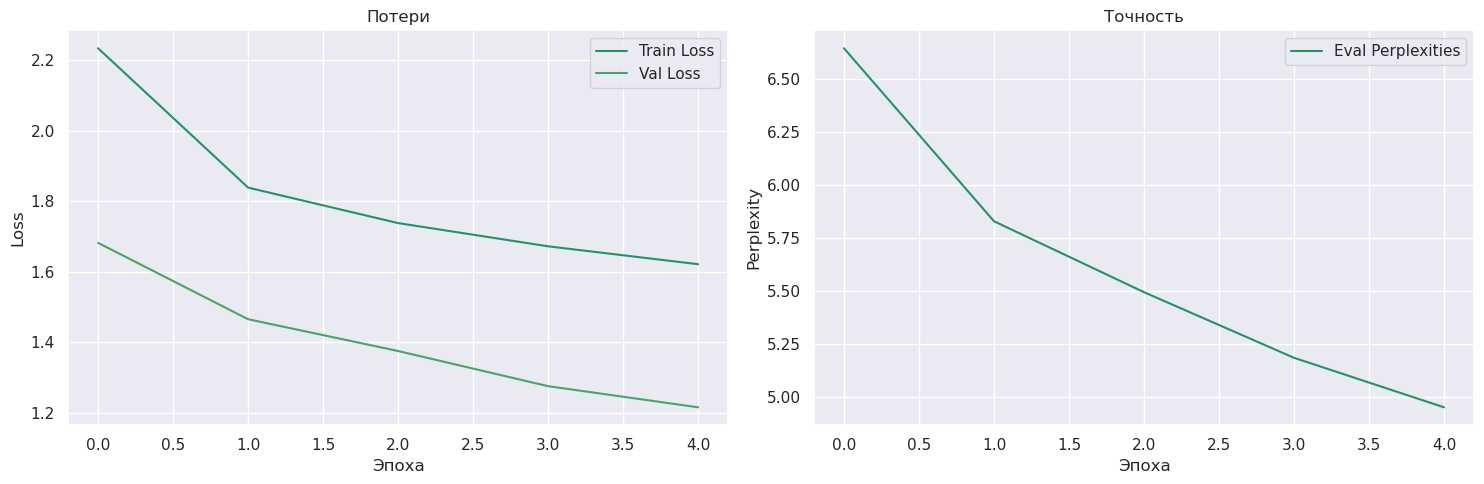

Перплексия модели на тесте: 4.9415


In [28]:
model1w = LSTMModel(hidden_dim=512, vocab_size=len(vocab), num_layers=1, dropout=0.1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model1w.parameters(), lr=0.01)

# обучение модели
trained_model1w, history1w = train_model(
    model=model1w,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history1w)

# оценка на тестовых данных
test1 = evaluate(trained_model1w, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test1:.4f}")

 0  | Train Loss 10.3613 | Val Loss  9.9596 | Perplexities 20559.61 | LR  0.0100
Новый лучший результат Val Loss: 9.9596
 1  | Train Loss  7.7540 | Val Loss  4.8673 | Perplexities  125.84 | LR  0.0100
Новый лучший результат Val Loss: 4.8673
 2  | Train Loss  4.0239 | Val Loss  3.4880 | Perplexities   33.72 | LR  0.0100
Новый лучший результат Val Loss: 3.4880
 3  | Train Loss  3.3974 | Val Loss  3.2266 | Perplexities   26.30 | LR  0.0100
Новый лучший результат Val Loss: 3.2266
 4  | Train Loss  3.2310 | Val Loss  3.1086 | Perplexities   23.57 | LR  0.0100
Новый лучший результат Val Loss: 3.1086
Загружены лучшие веса модели
Обучение завершено


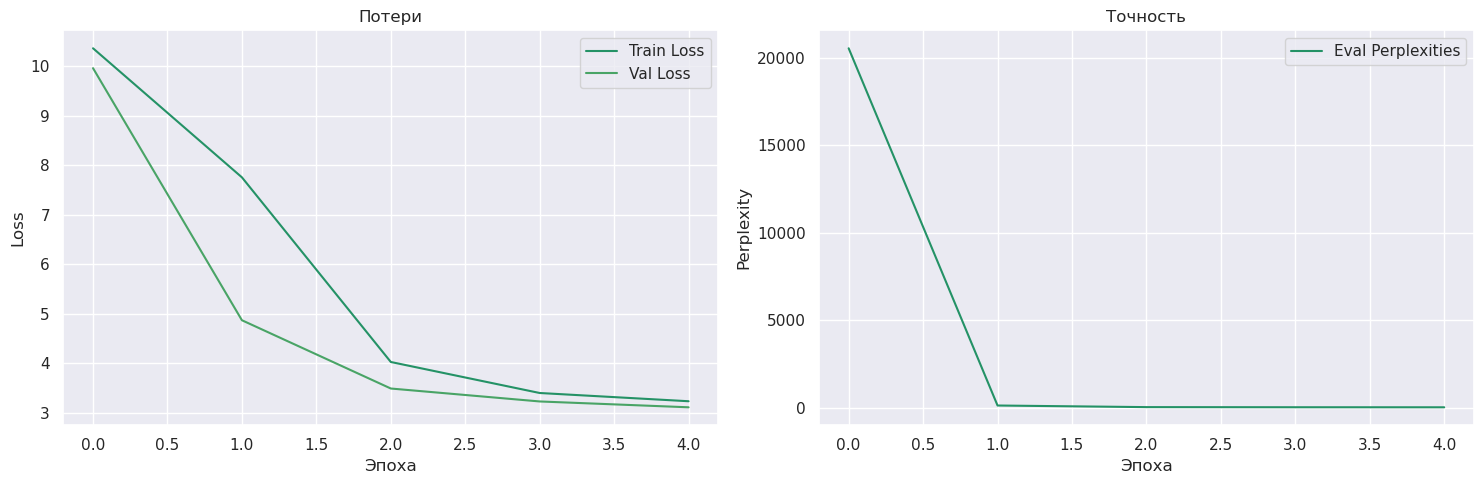

Перплексия модели на тесте: 23.0730


In [29]:
model1s = LSTMModel(hidden_dim=512, vocab_size=len(vocab), num_layers=1, dropout=0.1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.SGD(model1s.parameters(), lr=0.01)

# обучение модели
trained_model1s, history1s = train_model(
    model=model1s,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history1s)

# оценка на тестовых данных
test1 = evaluate(trained_model1s, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test1:.4f}")

 0  | Train Loss  6.2769 | Val Loss  3.1862 | Perplexities   37.20 | LR  0.0100
Новый лучший результат Val Loss: 3.1862
 1  | Train Loss  3.0468 | Val Loss  2.9325 | Perplexities   36.62 | LR  0.0100
Новый лучший результат Val Loss: 2.9325
 2  | Train Loss  2.7224 | Val Loss  2.4683 | Perplexities   29.84 | LR  0.0100
Новый лучший результат Val Loss: 2.4683
 3  | Train Loss  2.3738 | Val Loss  1.8662 | Perplexities   19.45 | LR  0.0100
Новый лучший результат Val Loss: 1.8662
 4  | Train Loss  2.1471 | Val Loss  1.6628 | Perplexities   16.69 | LR  0.0100
Новый лучший результат Val Loss: 1.6628
Загружены лучшие веса модели
Обучение завершено


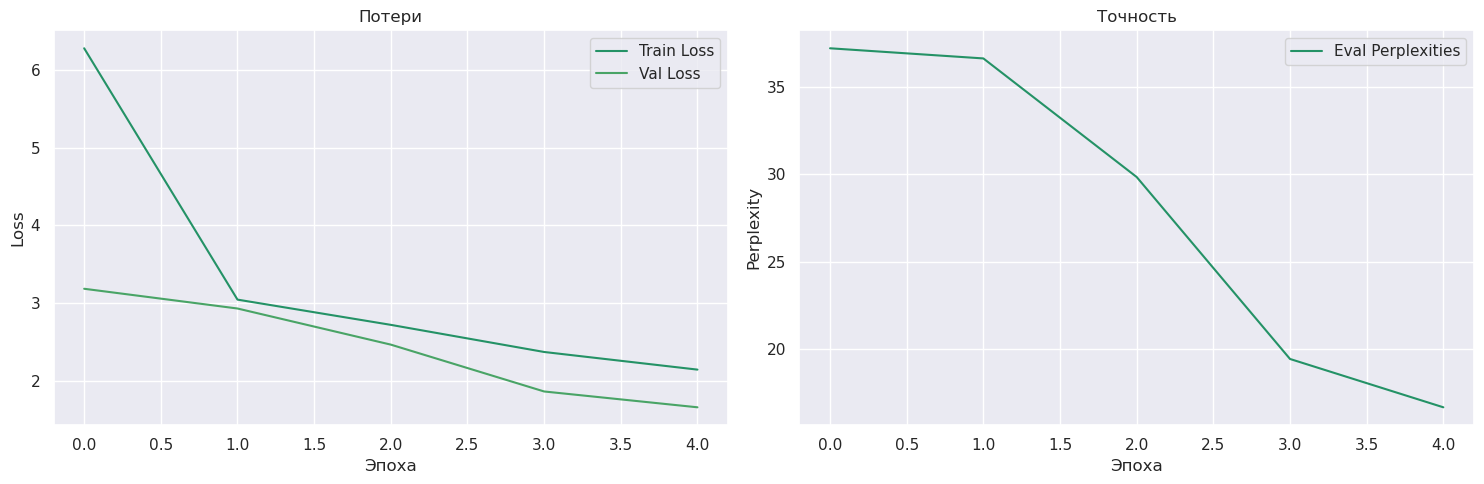

Перплексия модели на тесте: 16.6755


In [30]:
model1r = LSTMModel(hidden_dim=512, vocab_size=len(vocab), num_layers=1, dropout=0.1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.RMSprop(model1r.parameters(), lr=0.01)

# обучение модели
trained_model1r, history1r = train_model(
    model=model1r,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history1r)

# оценка на тестовых данных
test1 = evaluate(trained_model1r, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test1:.4f}")

Adam: 5.3

AdamW: 4.9

SGD: 23.1

RMSprop: 16.7

Выбираем AdamW

#### Обучение основной модели эксперимента 1

 0  | Train Loss  2.2422 | Val Loss  1.6978 | Perplexities    6.71 | LR  0.0100
Новый лучший результат Val Loss: 1.6978
 1  | Train Loss  1.8394 | Val Loss  1.5336 | Perplexities    5.93 | LR  0.0100
Новый лучший результат Val Loss: 1.5336
 2  | Train Loss  1.7451 | Val Loss  1.3944 | Perplexities    5.45 | LR  0.0100
Новый лучший результат Val Loss: 1.3944
 3  | Train Loss  1.6804 | Val Loss  1.2961 | Perplexities    5.15 | LR  0.0100
Новый лучший результат Val Loss: 1.2961
 4  | Train Loss  1.6323 | Val Loss  1.2393 | Perplexities    4.95 | LR  0.0030
Новый лучший результат Val Loss: 1.2393
 5  | Train Loss  1.5130 | Val Loss  1.2054 | Perplexities    4.43 | LR  0.0030
Новый лучший результат Val Loss: 1.2054
 6  | Train Loss  1.4691 | Val Loss  1.1382 | Perplexities    4.35 | LR  0.0030
Новый лучший результат Val Loss: 1.1382
 7  | Train Loss  1.4409 | Val Loss  1.0903 | Perplexities    4.29 | LR  0.0030
Новый лучший результат Val Loss: 1.0903
 8  | Train Loss  1.4184 | Val Loss  1.0

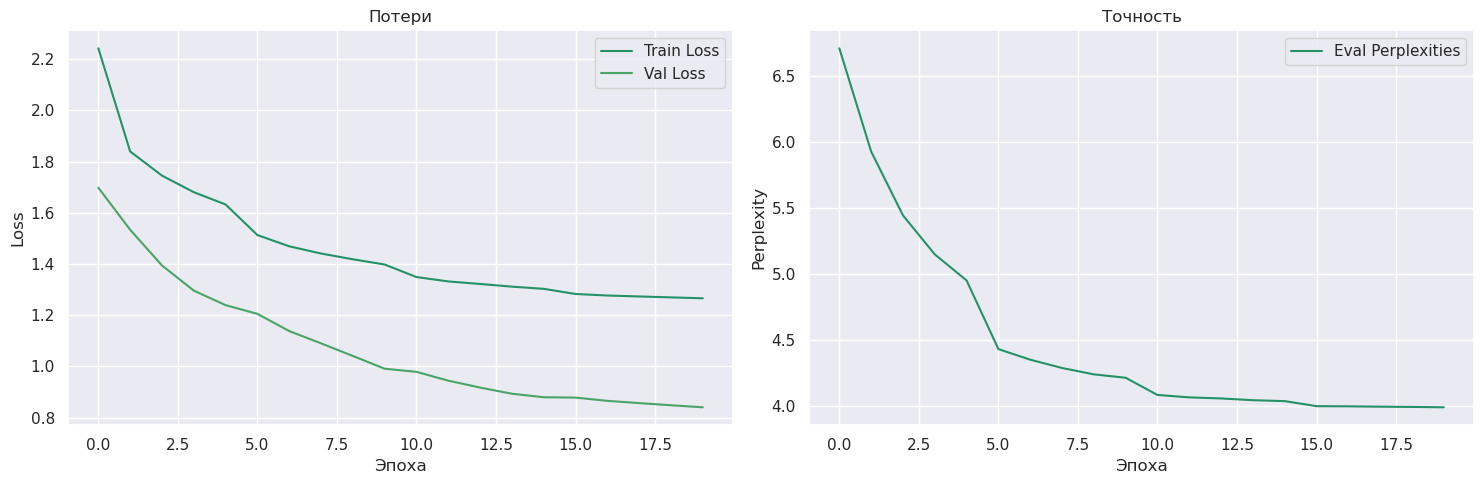

Перплексия модели LSTM на тесте: 3.9641


In [31]:
model1 = LSTMModel(hidden_dim=512, vocab_size=len(vocab), num_layers=1, dropout=0.1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model1.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)

# обучение модели
trained_model1, history1 = train_model(
    model=model1,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=20,
    patience=7
)

plot_training_history(history1)

# оценка на тестовых данных
test1 = evaluate(trained_model1, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели LSTM на тесте: {test1:.4f}")

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [95]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [23]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=word2ind['<pad>'])
        # GRU
        self.gru = nn.GRU(
            embedding_dim, 
            hidden_dim, 
            num_layers=num_layers, 
            batch_first=True
        )
        
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, vocab_size)
        self.batchnorm = nn.LayerNorm(normalized_shape=hidden_dim)
        self.non_lin = nn.Tanh()
        
    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_batch)
        gru_out, _ = self.gru(embedded)
        logits = self.batchnorm(self.linear(self.non_lin(gru_out)))
        logits = self.output(self.non_lin(logits))
        return logits

#### Выбор количества слоёв

 0  | Train Loss  2.0182 | Val Loss  1.3706 | Perplexities    5.62 | LR  0.0100
Новый лучший результат Val Loss: 1.3706
 1  | Train Loss  1.6416 | Val Loss  1.2466 | Perplexities    5.13 | LR  0.0100
Новый лучший результат Val Loss: 1.2466
 2  | Train Loss  1.5855 | Val Loss  1.2104 | Perplexities    5.01 | LR  0.0100
Новый лучший результат Val Loss: 1.2104
 3  | Train Loss  1.5567 | Val Loss  1.2022 | Perplexities    4.97 | LR  0.0100
Новый лучший результат Val Loss: 1.2022
 4  | Train Loss  1.5488 | Val Loss  1.1961 | Perplexities    4.98 | LR  0.0100
Новый лучший результат Val Loss: 1.1961
Загружены лучшие веса модели
Обучение завершено


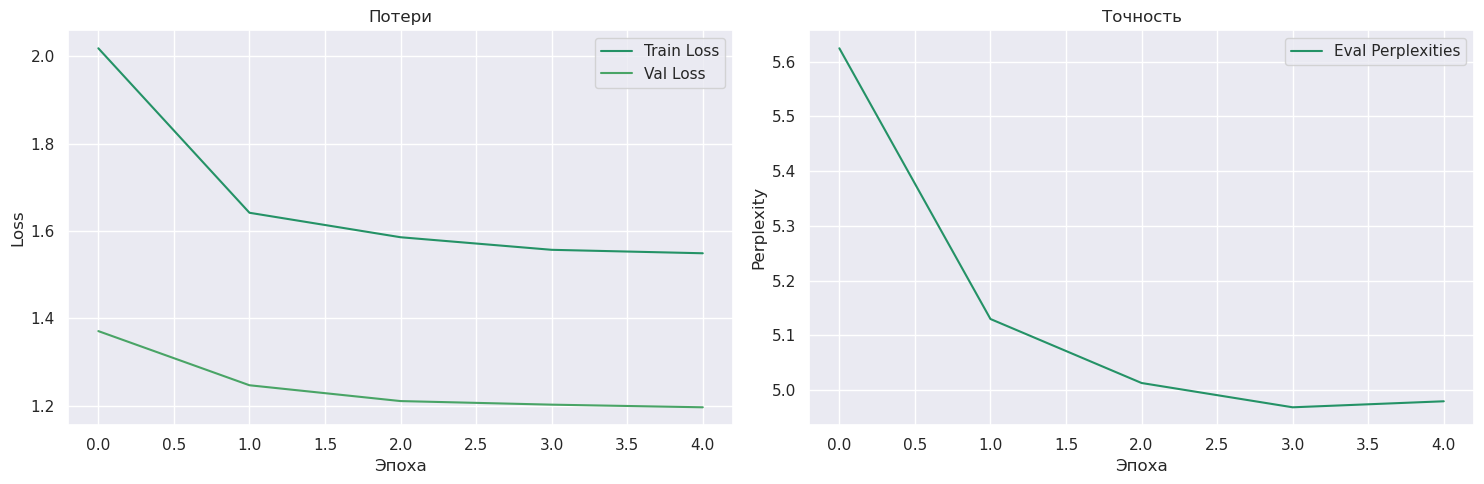

Перплексия модели на тесте: 4.9481


In [33]:
model2 = GRUModel(hidden_dim=512, vocab_size=len(vocab), embedding_dim=256, num_layers=1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)

# обучение модели
trained_model2, history2 = train_model(
    model=model2,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history2)

# оценка на тестовых данных
test2 = evaluate(trained_model2, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test2:.4f}")

 0  | Train Loss  2.3590 | Val Loss  1.6405 | Perplexities    6.87 | LR  0.0100
Новый лучший результат Val Loss: 1.6405
 1  | Train Loss  1.7899 | Val Loss  1.4466 | Perplexities    5.76 | LR  0.0100
Новый лучший результат Val Loss: 1.4466
 2  | Train Loss  1.7033 | Val Loss  1.3838 | Perplexities    5.51 | LR  0.0100
Новый лучший результат Val Loss: 1.3838
 3  | Train Loss  1.6808 | Val Loss  1.4001 | Perplexities    5.46 | LR  0.0100
Ранняя остановка: 1/5
 4  | Train Loss  1.6780 | Val Loss  1.3812 | Perplexities    5.48 | LR  0.0100
Новый лучший результат Val Loss: 1.3812
Загружены лучшие веса модели
Обучение завершено


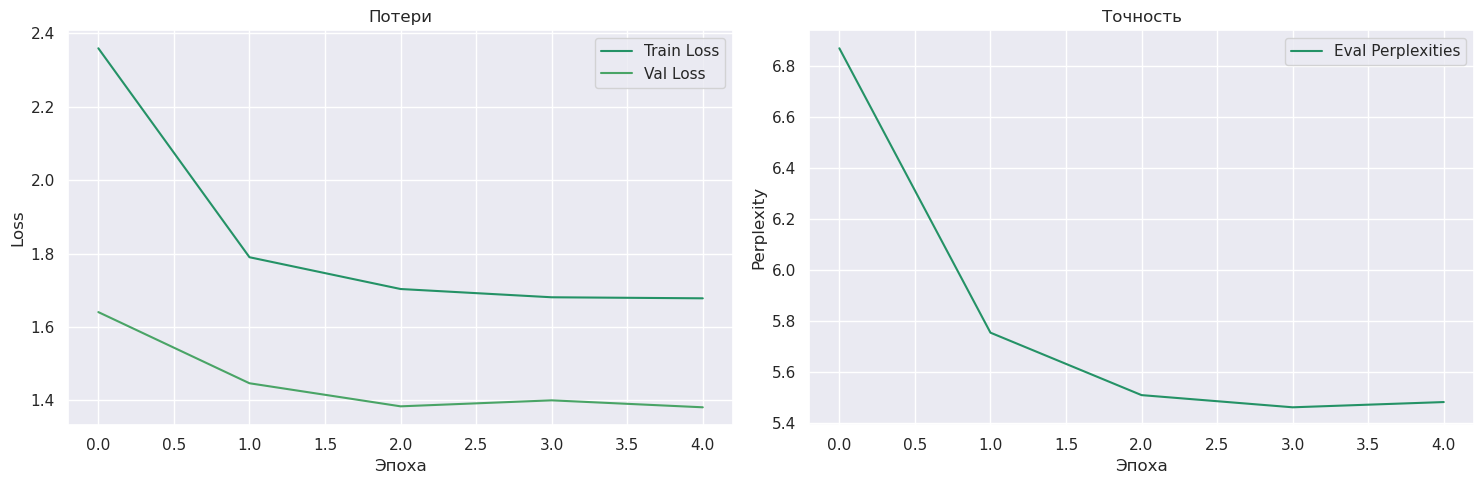

Перплексия модели на тесте: 5.4606


In [34]:
model2_1 = GRUModel(hidden_dim=512, vocab_size=len(vocab), embedding_dim=256, num_layers=2)
optimizer = torch.optim.Adam(model2_1.parameters(), lr=0.01)

# обучение модели
trained_model2_1, history2_1 = train_model(
    model=model2_1,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history2_1)

# оценка на тестовых данных
test2 = evaluate(trained_model2_1, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test2:.4f}")

 0  | Train Loss  2.8957 | Val Loss  2.6067 | Perplexities   14.28 | LR  0.0100
Новый лучший результат Val Loss: 2.6067
 1  | Train Loss  2.3296 | Val Loss  2.1533 | Perplexities    9.55 | LR  0.0100
Новый лучший результат Val Loss: 2.1533
 2  | Train Loss  2.1251 | Val Loss  1.9837 | Perplexities    8.05 | LR  0.0100
Новый лучший результат Val Loss: 1.9837
 3  | Train Loss  2.0289 | Val Loss  1.9090 | Perplexities    7.53 | LR  0.0100
Новый лучший результат Val Loss: 1.9090
 4  | Train Loss  1.9894 | Val Loss  1.9081 | Perplexities    7.51 | LR  0.0100
Новый лучший результат Val Loss: 1.9081
Загружены лучшие веса модели
Обучение завершено


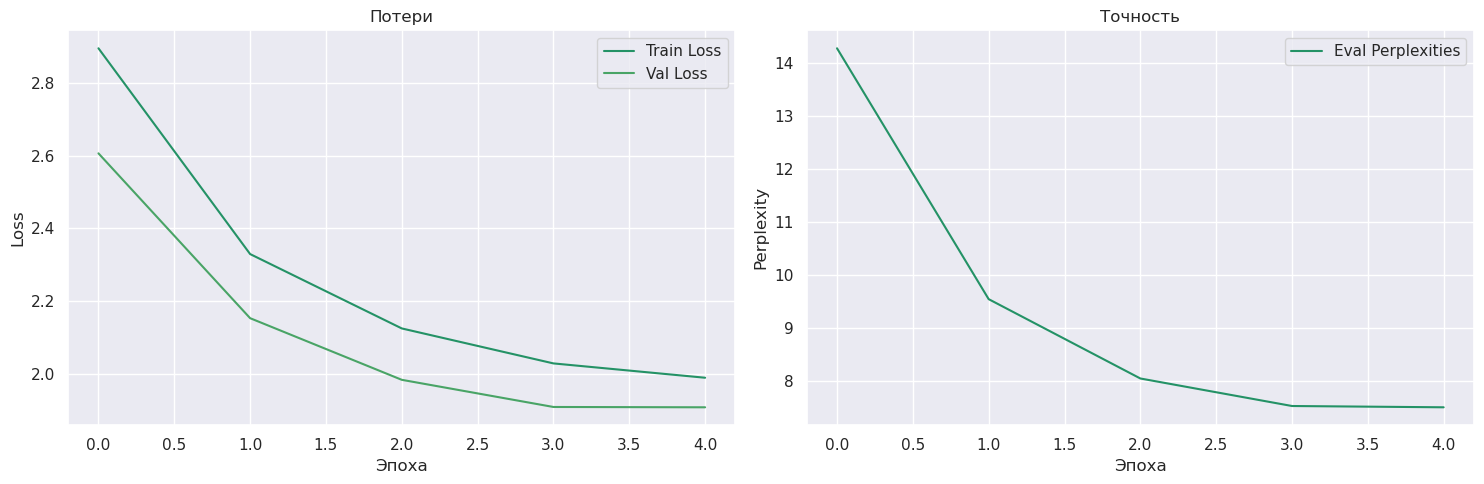

Перплексия модели на тесте: 7.4326


In [46]:
model2_2 = GRUModel(hidden_dim=512, vocab_size=len(vocab), embedding_dim=256, num_layers=3)
optimizer = torch.optim.Adam(model2_2.parameters(), lr=0.01)

# обучение модели
trained_model2_2, history2_2 = train_model(
    model=model2_2,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history2_2)

# оценка на тестовых данных
test2 = evaluate(trained_model2_2, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test2:.4f}")

1 слой: 4.9

2 слоя: 5.5

3 слоя: 7.4

Выбираем 1 слой.

#### Выбор оптимизатора

 0  | Train Loss  2.0687 | Val Loss  1.3624 | Perplexities    5.58 | LR  0.0100
Новый лучший результат Val Loss: 1.3624
 1  | Train Loss  1.6555 | Val Loss  1.2260 | Perplexities    5.02 | LR  0.0100
Новый лучший результат Val Loss: 1.2260
 2  | Train Loss  1.5916 | Val Loss  1.1991 | Perplexities    4.89 | LR  0.0100
Новый лучший результат Val Loss: 1.1991
 3  | Train Loss  1.5572 | Val Loss  1.1595 | Perplexities    4.84 | LR  0.0100
Новый лучший результат Val Loss: 1.1595
 4  | Train Loss  1.5479 | Val Loss  1.1733 | Perplexities    4.82 | LR  0.0100
Ранняя остановка: 1/5
Загружены лучшие веса модели
Обучение завершено


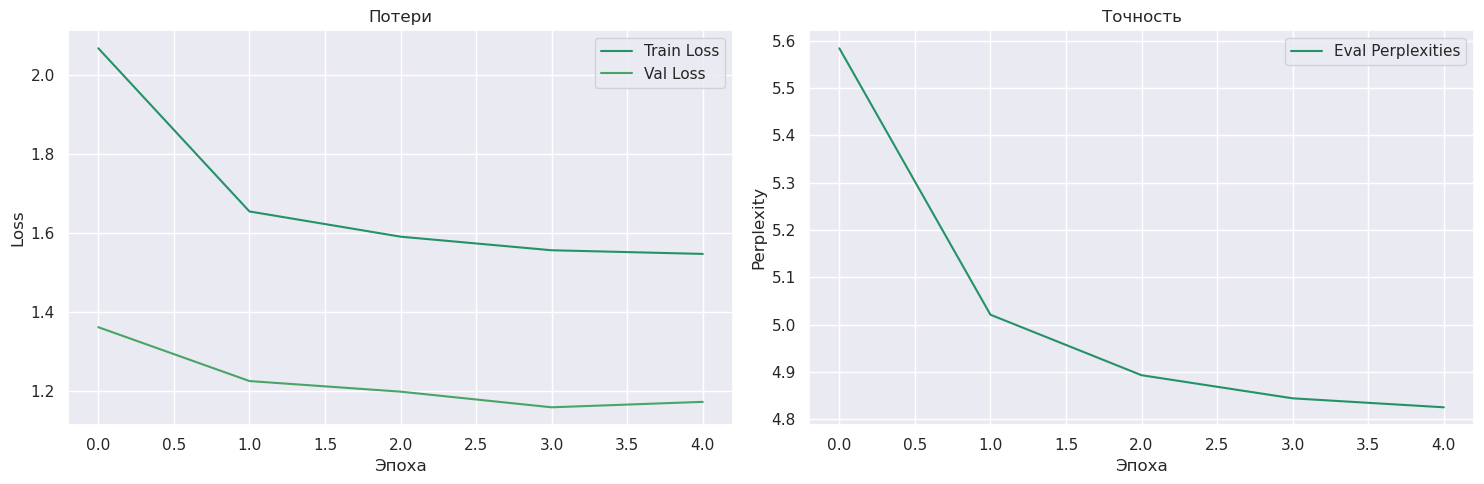

Перплексия модели на тесте: 4.9942


In [28]:
model2a = GRUModel(hidden_dim=512, vocab_size=len(vocab), embedding_dim=256, num_layers=1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model2a.parameters(), lr=0.01)

# обучение модели
trained_model2a, history2a = train_model(
    model=model2a,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history2a)

# оценка на тестовых данных
test2 = evaluate(trained_model2a, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test2:.4f}")

 0  | Train Loss  2.1035 | Val Loss  1.4319 | Perplexities    5.71 | LR  0.0100
Новый лучший результат Val Loss: 1.4319
 1  | Train Loss  1.6679 | Val Loss  1.2831 | Perplexities    5.12 | LR  0.0100
Новый лучший результат Val Loss: 1.2831
 2  | Train Loss  1.5932 | Val Loss  1.2114 | Perplexities    4.91 | LR  0.0100
Новый лучший результат Val Loss: 1.2114
 3  | Train Loss  1.5550 | Val Loss  1.1584 | Perplexities    4.78 | LR  0.0100
Новый лучший результат Val Loss: 1.1584
 4  | Train Loss  1.5331 | Val Loss  1.1428 | Perplexities    4.73 | LR  0.0100
Новый лучший результат Val Loss: 1.1428
Загружены лучшие веса модели
Обучение завершено


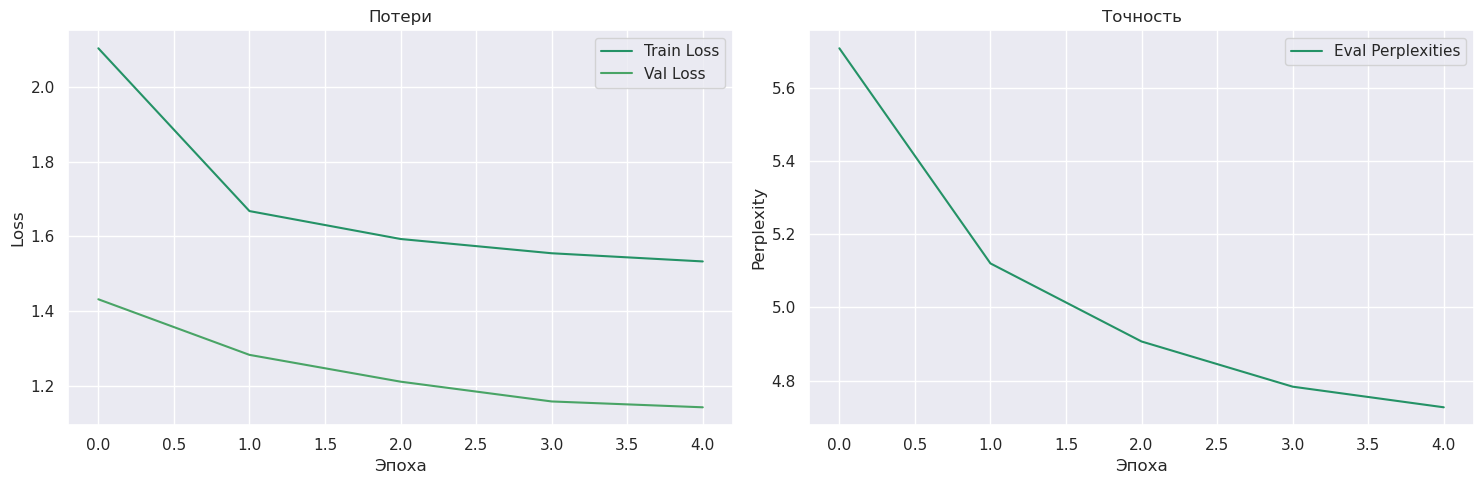

Перплексия модели на тесте: 4.8920


In [24]:
model2w = GRUModel(hidden_dim=512, vocab_size=len(vocab), embedding_dim=256, num_layers=1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model2w.parameters(), lr=0.01)

# обучение модели
trained_model2w, history2w = train_model(
    model=model2w,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history2w)

# оценка на тестовых данных
test2 = evaluate(trained_model2w, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test2:.4f}")

 0  | Train Loss  5.3376 | Val Loss  3.3467 | Perplexities   27.09 | LR  0.0100
Новый лучший результат Val Loss: 3.3467
 1  | Train Loss  3.0287 | Val Loss  2.8989 | Perplexities   16.84 | LR  0.0100
Новый лучший результат Val Loss: 2.8989
 2  | Train Loss  2.7491 | Val Loss  2.7324 | Perplexities   14.21 | LR  0.0100
Новый лучший результат Val Loss: 2.7324
 3  | Train Loss  2.6180 | Val Loss  2.6216 | Perplexities   12.87 | LR  0.0100
Новый лучший результат Val Loss: 2.6216
 4  | Train Loss  2.5318 | Val Loss  2.5338 | Perplexities   11.98 | LR  0.0100
Новый лучший результат Val Loss: 2.5338
Загружены лучшие веса модели
Обучение завершено


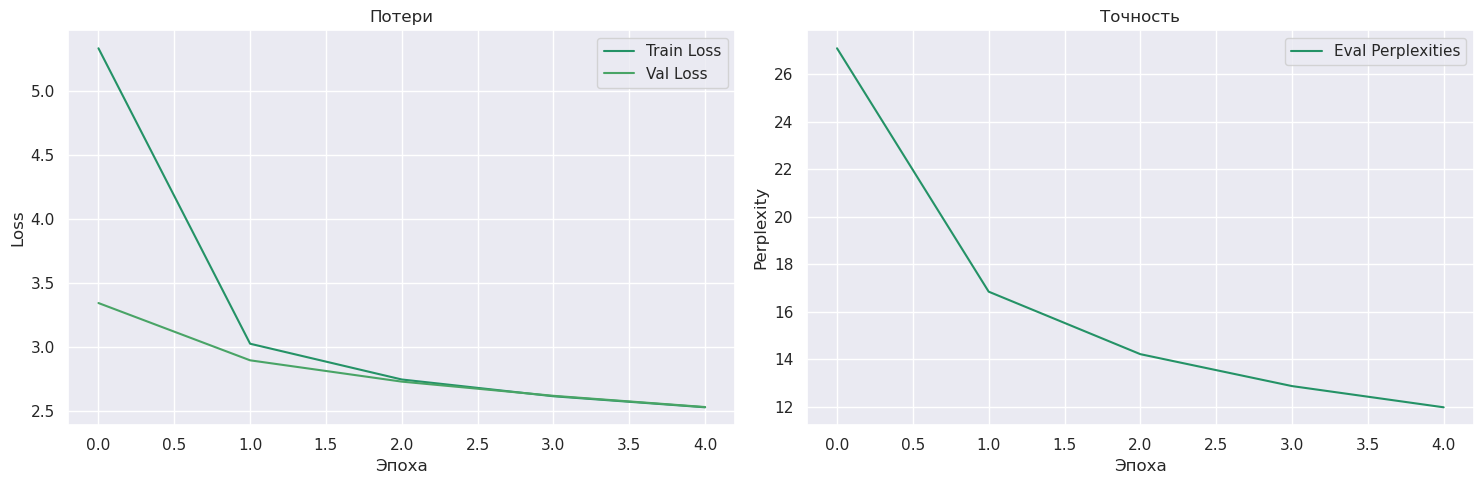

Перплексия модели на тесте: 12.0539


In [ ]:
model2s = GRUModel(hidden_dim=512, vocab_size=len(vocab), embedding_dim=256, num_layers=1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.SGD(model2s.parameters(), lr=0.01)

# обучение модели
trained_model2s, history2s = train_model(
    model=model2s,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history2s)

# оценка на тестовых данных
test2 = evaluate(trained_model2s, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test2:.4f}")

 0  | Train Loss  4.1923 | Val Loss  2.3666 | Perplexities   13.28 | LR  0.0100
Новый лучший результат Val Loss: 2.3666
 1  | Train Loss  2.3145 | Val Loss  2.1026 | Perplexities   11.08 | LR  0.0100
Новый лучший результат Val Loss: 2.1026
 2  | Train Loss  2.1329 | Val Loss  1.7842 | Perplexities    8.72 | LR  0.0100
Новый лучший результат Val Loss: 1.7842
 3  | Train Loss  2.0007 | Val Loss  1.7112 | Perplexities    8.46 | LR  0.0100
Новый лучший результат Val Loss: 1.7112
 4  | Train Loss  1.9114 | Val Loss  1.5640 | Perplexities    7.56 | LR  0.0100
Новый лучший результат Val Loss: 1.5640
Загружены лучшие веса модели
Обучение завершено


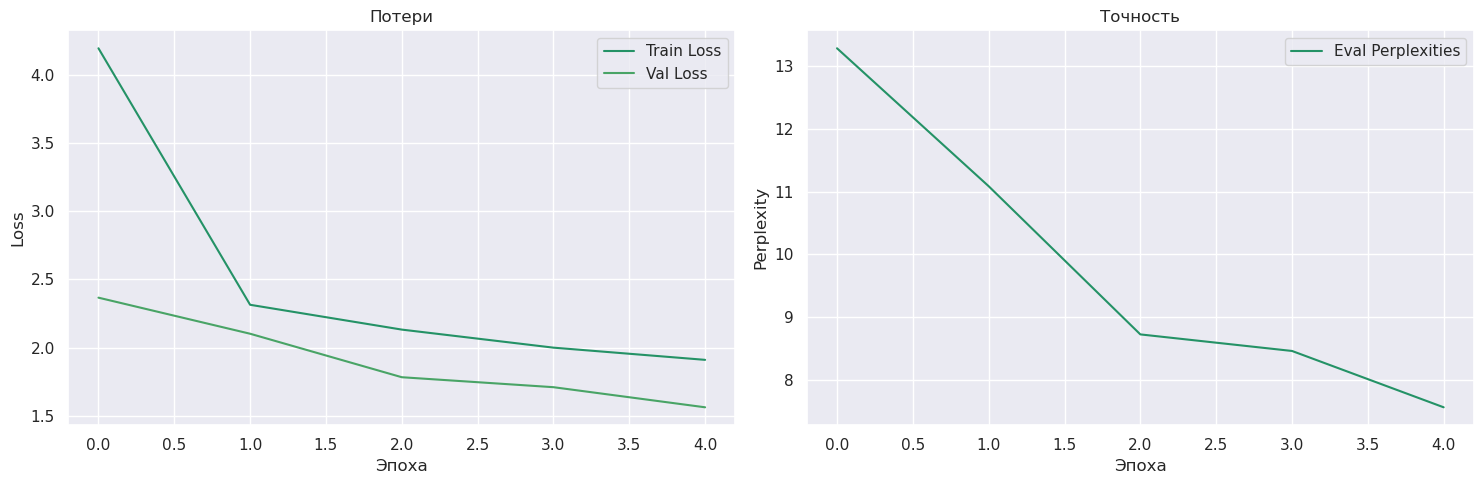

Перплексия модели на тесте: 7.6526


In [ ]:
model2r = GRUModel(hidden_dim=512, vocab_size=len(vocab), embedding_dim=256, num_layers=1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.RMSprop(model2r.parameters(), lr=0.01)

# обучение модели
trained_model2r, history2r = train_model(
    model=model2r,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=5
)

plot_training_history(history2r)

# оценка на тестовых данных
test2 = evaluate(trained_model2r, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели на тесте: {test2:.4f}")

Adam: 5

AdamW: 4.89

SGD: 12.1

RMSprop: 7.7

Выбираем AdamW

#### Обучение основной модели эксперимента 2

 0  | Train Loss  2.0200 | Val Loss  1.3795 | Perplexities    5.58 | LR  0.0100
Новый лучший результат Val Loss: 1.3795
 1  | Train Loss  1.6526 | Val Loss  1.2589 | Perplexities    5.03 | LR  0.0100
Новый лучший результат Val Loss: 1.2589
 2  | Train Loss  1.5887 | Val Loss  1.1845 | Perplexities    4.91 | LR  0.0030
Новый лучший результат Val Loss: 1.1845
 3  | Train Loss  1.4631 | Val Loss  1.1492 | Perplexities    4.36 | LR  0.0030
Новый лучший результат Val Loss: 1.1492
 4  | Train Loss  1.4057 | Val Loss  1.0479 | Perplexities    4.27 | LR  0.0030
Новый лучший результат Val Loss: 1.0479
 5  | Train Loss  1.3722 | Val Loss  0.9811 | Perplexities    4.22 | LR  0.0009
Новый лучший результат Val Loss: 0.9811
 6  | Train Loss  1.3033 | Val Loss  0.9526 | Perplexities    4.06 | LR  0.0009
Новый лучший результат Val Loss: 0.9526
 7  | Train Loss  1.2720 | Val Loss  0.9015 | Perplexities    4.05 | LR  0.0009
Новый лучший результат Val Loss: 0.9015
 8  | Train Loss  1.2505 | Val Loss  0.8

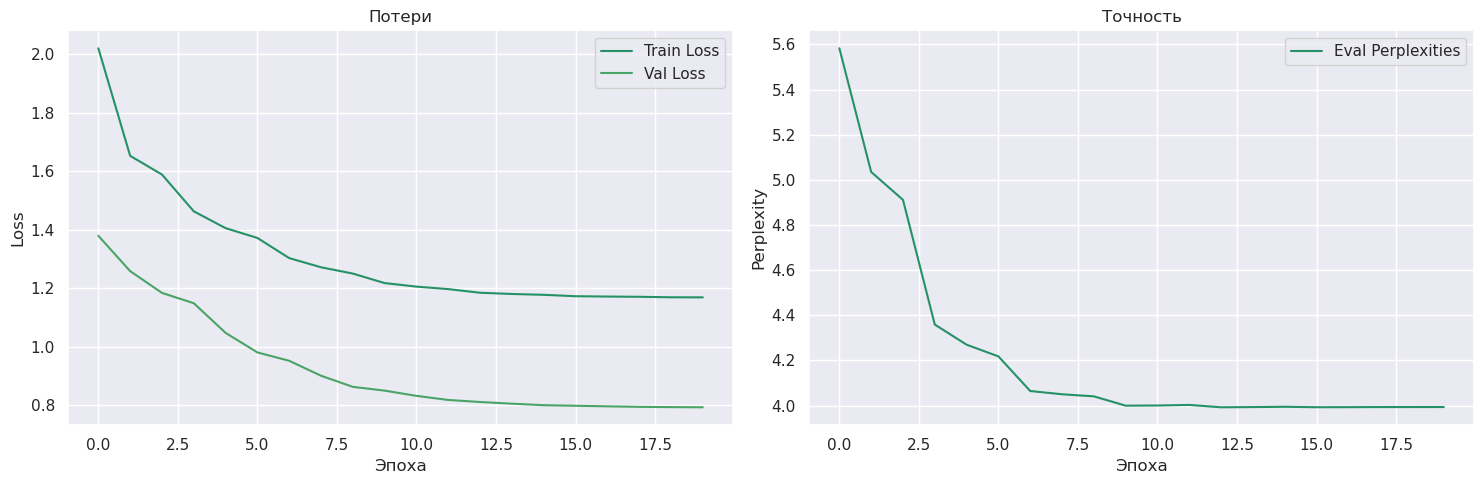

Перплексия модели GRU на тесте: 4.1545


In [29]:
model2 = GRUModel(hidden_dim=512, vocab_size=len(vocab), embedding_dim=256, num_layers=1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model2.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.3)

# обучение модели
trained_model2, history2 = train_model(
    model=model2,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=20,
    patience=7
)

plot_training_history(history2)

# оценка на тестовых данных
test2 = evaluate(trained_model2, nn.CrossEntropyLoss(ignore_index=word2ind['<pad>']), test_dataloader)
print(f"Перплексия модели GRU на тесте: {test2:.4f}")

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

**Базовая модель**

Структура: слой эмбеддингов, RNN с 2-мя слоями, Tanh, линейный слой, слой регуляризации Dropout, Tanh, линейный слой. Оптимизатор Adam. 20 эпох.

Перплексия 4.3
***
Далее в каждом из экспериментов была проведена серия небольших экспериментов для подбора оптимального количества слоёв и оптимизатора.

**Эксперимент 1**

Структура: слой эмбеддингов, LSTM с 1-м слоем, слой регуляризации Dropout, Tanh, линейный слой, слой регуляризации Dropout, Tanh, линейный слой. Оптимизатор AdamW, изменение скорости обучения gamma 0.3 на каждой 5-й эпохе, 20 эпох.

Перплексия 3.9641

**Эксперимент 2**

Структура: слой эмбеддингов, GRU с 1-м слоем, Tanh, линейный слой, слой регуляризации LayerNorm, Tanh, линейный слой. Оптимизатор AdamW, изменение скорости обучения gamma 0.3 на каждой 5-й эпохе, 20 эпох.

Перплексия 4.1545

В целом оба эксперимента показали результаты лучше базовой модели. Результаты архитектуры с LSTM лучшие из проведённых экспериментов.

*Идеи для улучшения качества моделей:* увеличение hidden_size и embedding_dim, двунаправленная LSTM, изменение архитектуры RNN на, например, Transformer, увеличение слоёв RNN с усилением регуляризации.